## FORMA 1 - GRADIENT DESCENT

El **descenso de gradiente** es un algoritmo de optimización que se utiliza para ajustar los parámetros de un modelo de regresión lineal. El objetivo es encontrar los valores de los parámetros que minimizan la función de costo, que mide la diferencia entre las predicciones del modelo y los valores reales.

El descenso de gradiente funciona iterativamente, actualizando los valores de los parámetros en cada iteración para reducir la función de costo. En cada iteración, se calcula el gradiente de la función de costo con respecto a los parámetros y se actualizan los parámetros en la dirección opuesta al gradiente. La tasa de aprendizaje controla el tamaño de los pasos que se dan en cada iteración.

Para aplicar el descenso de gradiente a un modelo de regresión lineal, se utiliza el **MSE** como función de costo. El MSE mide la diferencia entre las predicciones del modelo y los valores reales al cuadrado. El objetivo es minimizar el MSE ajustando los valores de los parámetros.


Paso a paso del algoritmo de descenso de gradiente para optimizar un modelo de regresión lineal:

1. Inicializa los parámetros del modelo con valores aleatorios.
2. Calcula la función de costo utilizando los valores actuales de los parámetros.
3. Calcula el gradiente de la función de costo con respecto a los parámetros.
4. Actualiza los parámetros en la dirección opuesta al gradiente multiplicado por la tasa de aprendizaje.
5. Repite los pasos 2-4 hasta que la función de costo converja a un mínimo o decidas parar.

COMO LO TENEIS QUE HACER VOSOTROS:

1. Inicializa los parametros `m` y `c` a cero o con valores aleatorios.
2. Elegimos un numero de iteraciones (eg. 100) y un ``learning_rate`` (eg. 0.01)
3. Inicializamos valores para X e Y. X que sean numpy arrays de 10 o 20 numeros (eg. range(10)) y la Y pueden ser parecida a la X pero con numeros arriba o abajo para simular aletoriedad (eg. 2,2,4,2,5,7,6,9,8,10)
4. Arrancamos el bucle for.
5. Calculamos la derivada del error respecto de `m` y `c`:
    - `dm = 2/n*sum((y-(m*x+c))*(-x))`
    - `dc = 2/n*sum((y-(m*x+c))*(-1))`
6. Actualizamos los parametros: `m=m-dm*lr` y `c=c-dc*lr`
7. Cada iteracion haceis un plot de la linea `x` y `m*x+c` respecto a los puntos originales (plot de x e y) y os guardais el las imagenes (Si haceis 100 iteraciones, tendreis 100 imagenes. Podeis valorar solo guardar por ejemplo cada 5 iteraciones por no hacer tantos plots).
8. Una vez terminamos printeamos m y c y con los plots generados teneis quer buscar alguna libreria en python y montar un gif con las imagenes de los plots:

![gif](https://th.bing.com/th/id/R.79e22f97090c346d704a68f7151e8cda?rik=oJV36GZyA1otdA&riu=http%3a%2f%2fcdn-images-1.medium.com%2fmax%2f640%2f1*eeIvlwkMNG1wSmj3FR6M2g.gif&ehk=0NUalJOl26VxY8ndNrkpV7GwYM1NVtJ5kMxU6jm5jB0%3d&risl=&pid=ImgRaw&r=0)

NOTA**: Todos los valores son orientativos. Podeis modificar los datos como querais. De hecho, os animo a que probeis y trasteeis.

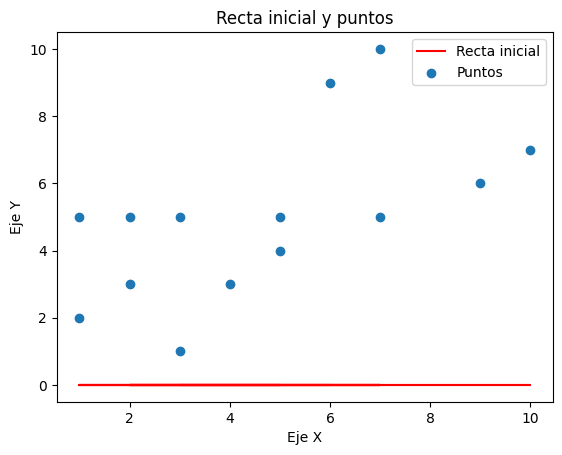

m final: 0.5223322060050216
c final: 2.574864260884718


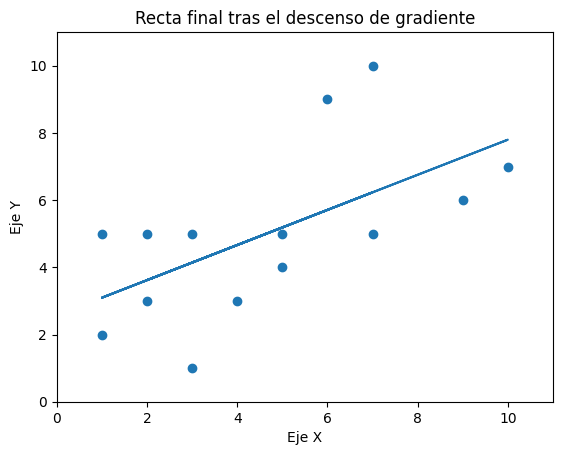

GIF guardado como 'descenso_gradiente.gif'


In [52]:
# IMPORTAMOS LAS LIBRERÍAS
import numpy as np
import matplotlib.pyplot as plt
import os

# LIBRERÍAS PARA EL GIF :
import imageio.v2 as imageio
from glob import glob

# 1. Inicializa los parametros `m` y `c`
m = 0
c = 0

# 2. Elegimos número de iteraciones y learning rate
iteraciones = 2000
learning_rate = 0.01

# 3. Inicializamos valores para x e y.
x = np.array([3,1,7,3,4,5,2,7,5,2,10,9,1,6])
y = np.array([1,2,10,5,3,5,3,5,4,5,7,6,5,9])

# Carpeta para las imágenes
os.makedirs("frames", exist_ok=True)

# Recta inicial con los valores iniciales de m y c
recta = m*x + c

plt.figure()
plt.xlabel("Eje X")
plt.ylabel("Eje Y")
plt.title("Recta inicial y puntos")
plt.plot(x, recta, label='Recta inicial', color='red')
plt.scatter(x, y, label='Puntos')
plt.legend()
plt.show()

# 4. Arrancamos el bucle for.
# 5. Calculamos la derivada del error respecto de `m` y `c`:
# 6. Actualizamos los parametros: `m=m-dm*lr` y `c=c-dc*lr`
# 7. Cada iteracion haceis un plot de la linea `x` y `m*x+c` respecto a los puntos originales (plot de x e y) y os guardais el las imagenes 
# (Si haceis 100 iteraciones, tendreis 100 imagenes. Podeis valorar solo guardar por ejemplo cada 5 iteraciones por no hacer tantos plots).

# inicio del bucle (punto 4)
for i in range(iteraciones): 
    y_nueva = m*x + c

    # derivadas del error (punto 5)
    dm = (2/len(x))*np.sum((y - y_nueva) * (-x))
    dc = (2/len(x))*np.sum((y - y_nueva) * (-1))

    # actualización de parámetros (punto 6)
    m = m - dm*learning_rate
    c = c - dc*learning_rate

    # (punto 7) cada 10 iteraciones, ploteamos y guardamos
    if i % 10 == 0 : 
        plt.figure()
        plt.xlim(0, 11)
        plt.ylim(0, 11)
        plt.scatter(x, y)
        plt.plot(x, m*x + c, color='red')
        plt.title(f"Iteración {i}")
        plt.xlabel("Eje X")
        plt.ylabel("Eje Y")
        plt.savefig(f"frames/iteracion_{i:04d}.png")
        plt.close()
        

# 8. Imprimimos los valores finales de los parámetros m y c.
print("m final:", m)
print("c final:", c)

# Plot final
plt.figure()
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.scatter(x, y)
plt.plot(x, m*x + c)
plt.title("Recta final tras el descenso de gradiente")
plt.xlabel("Eje X")
plt.ylabel("Eje Y")
plt.show()

# Montamos el GIF con las imágenes guardadas
frames = []

# Ordenamos las imágenes por nombre (iteracion_0000, 0010, 0020, ...)
for filename in sorted(glob("frames/iteracion_*.png")):
    frames.append(imageio.imread(filename))

imageio.mimsave("descenso_gradiente.gif", frames, duration=0.2)
print("GIF guardado como 'descenso_gradiente.gif'")

Una vez probado diversos valores para la variable de "iteracciones" y de "learning rate", visualmente vamos comprobando que se ajuste lo mejor posible la recta de regresión a la nube de puntos. Sin embargo, sabemos que estos valores darán lugar a la recta más optima cuando al calcular el MSE el valor sea mínimo . 

Para obtener la recta óptima que ajusta mis datos, vamos a ir probando diversos valores de iteracciones y de learning_rate y observando la recta ploteada y comprobaremos con que valores se ajusta mejor la recta sin aumentar el valor del MSE. 

In [ ]:
# Comprobación de que sea la recta más adecuada.

# Analisis del error cuadrático medio (MSE)
MSE = np.mean((y_nueva - y)**2)
print("MSE:", MSE)

MSE: 3.625011898779505


Comenzando inicialmente con un valor para iteraciones de 100 y un valor para learning_rate de 0,0001 he observado que la recta no se ajustaba lo suficiente a la nube de puntos y que además el valor de MSE era "alto" en comparación con el del resultado correcto.

Seguidamente he aumentado a 0,01 el valor de learning_rate y he observado que la recta se ajustaba más y había reducido el MSE pero no acababa de ajustarse bien del todo.

Finalmente dejando dicho valor del learning_rate (0,01) y aumentando las iteraciones de 100 a 2000, he obtenido el valor más bajo de MSE y observando la gráfica final, un buen ajuste de la recta.

# FORMA 2 - ECUACION NORMAL

El modelo de Linear Regression es unico en todo el universo ML. Es el unico que se puede resolver de forma analitica resolviendo una ecuacion sin necesidad de optimizar usando por ejemplo el descenso de gradiente. Para resolverlo se usa una ecuacion que se llama ECUACION NORMAL.

La ecuación normal es una forma de resolver la regresión lineal sin utilizar el descenso de gradiente. En lugar de iterar para encontrar los valores de los parámetros que minimizan la función de costo, la ecuación normal calcula los valores de los parámetros directamente.
La ecuación normal para la regresión lineal simple es:

$$\theta=(X^{T}X)^{−1}X^{T}y$$
Donde θ es el vector de parámetros, X es la matriz de características, y es el vector de valores objetivo y −1 denota la inversa de una matriz.
La ecuación normal se deriva al igualar el gradiente de la función de costo a cero. La solución resultante es la que minimiza la función de costo.

AQUI TENEIS LA FORMULA RESUELTA: https://interactivechaos.com/es/manual/tutorial-de-machine-learning/la-ecuacion-normal

Buscadla y aplicarla con vuestros datos de `X` e ``y``, y os calcula directamente los parametros ``m`` y ``c``.

[2.57495003 0.52231845]


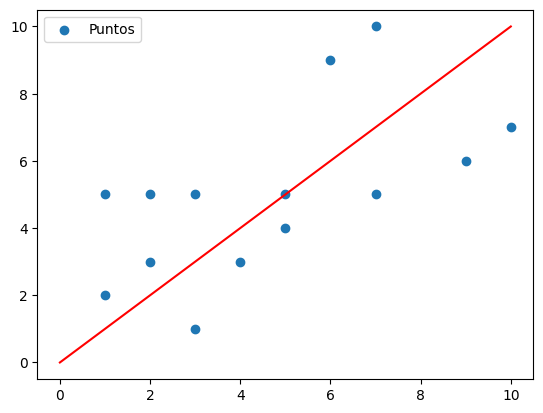

In [48]:
import seaborn as sns

x = np.array([3,1,7,3,4,5,2,7,5,2,10,9,1,6]).reshape(-1, 1) # se hace un reshape para que sea una matriz de una columna
y = np.array([1,2,10,5,3,5,3,5,4,5,7,6,5,9])

# Scatter plot de los datos
plt.scatter(x, y, label='Puntos')
sns.lineplot(x = [0, 10], y = [0, 10], color = "red")

# Matriz con columna de unos + x
x_1 = np.c_[np.ones((x.shape[0], 1)), x]  # (14, 2)

best_W = np.linalg.inv(x_1.T.dot(x_1)).dot(x_1.T).dot(y)
print(best_W)  

Como podemos observar con este segundo método, los valores obtenidos de m y c coinciden prácticamente con los del primer método y se observa un plot de una recta bastante ajustada a la nube de puntos.

# FORMA 3 - SKLEARN

Todos sabeis que si entrenamos un modelo de linear regression con sklearn podemos obtener los coeficientes con el metodo `.coef_` y el intercepto con `.intercept`.

Haz un fit del modelo con tus datos X e y, y comprueba que valores de coeficiente (m) y que valor de intercepto (c) te da

In [ ]:
# Libreria a añadir. 
from sklearn.linear_model import LinearRegression

# Valores de x e y seleccionados.
x = np.array([3,1,7,3,4,5,2,7,5,2,10,9,1,6]).reshape(-1, 1) # se hace un reshape porque sklearn necesita que x sea una matriz 2D
y = np.array([1,2,10,5,3,5,3,5,4,5,7,6,5,9])


regresion = LinearRegression().fit(x, y)
print(regresion.coef_)
print(regresion.intercept_)

[0.52231845]
2.5749500333111253


Finalmente, con este último método se obtienen también unos valores prácticamente idénticos a los de los métodos anteriores.

# CIERRE

Si lo habeis hecho bien, los tres metodos os han debido dar valores para m y c que deberian ser identicos o suuuper parecidos. Haz un print de los parametros en una tabla para compararlos y verificar que son iguales, como se muestra a continuación. (NOTA***, los valores son de ejemplo, no los vuestros)

<center>

| **Variable** | **Gradient descendt** | **Ecuacion normal** | **sklearn** |
|-------------|-------------------|----------------------|---------------------|
|m    |  0.3454772825034164  |  0.34527687296416937  |  0.34527687  |
|c |  3.321256418022657  |  3.322475570032573  |  3.322475570032573  |


y=m * x + c

</center>

In [ ]:
# RECOPILACIÓN DE RESULTADOS

# Librería a añadir
import pandas as pd

# 1. DESCENSO DE GRADIENTE
m_gd = m
c_gd = c

# 2. ECUACIÓN NORMAL
c_normal = best_W[0]
m_normal = best_W[1]

# 3. SKLEARN
m_sk = regresion.coef_[0]
c_sk = regresion.intercept_

# TABLA FINAL
tabla = pd.DataFrame({
    "Variable": ["m", "c"],
    "Gradient descent": [m_gd, c_gd],
    "Ecuacion normal": [m_normal, c_normal],
    "Sklearn": [m_sk, c_sk]
})

display(tabla)


,Variable,Gradient descent,Ecuacion normal,Sklearn
0,m,0.522332,0.522318,0.522318
1,c,2.574864,2.574950,2.574950


En conclusión, puedo comprobar que los tres modelos se han ajustado correctamente a la nube de puntos, con el menor error posible (al menos de todas las pruebas y cambios de parámetros que he ido probando) y que los 3 coinciden numéricamente tanto en el parámetro "m" como en el de "c"